In [11]:
import jax.numpy as jnp
import jax
from jaxtyping import PRNGKeyArray

from jax import Array
from jax.typing import ArrayLike
from typing import Optional

from jaxopt import ProjectedGradient
from jaxopt.projection import projection_simplex

import jax_dataloader as jdl
from typing import Any, Callable, final
from typing_extensions import override

import os


In [12]:
main_dir = "/mnt/home/levans/ensemble_reweighting/parsimonious_ensembles"
fig_dir = f"{main_dir}/figures/comparing_optimizations/hsp90"
data_dir = "/mnt/home/levans/ensemble_reweighting/cryo_reweighting_examples/data/likelihoods"


## Set plotting info

In [13]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# mpl.rcParams['text.usetex'] = True  # Uncomment for latex font in plots
plt.style.use(f"{main_dir}/my_style.mplstyle") # Use stylefile defined
plt.style.use("seaborn-v0_8-colorblind") # Use colorscheme from colorblind seaborn
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color'] # Save color list for reference


## Load Likelihood Matrix

In [14]:

log_likelihood = jnp.load(f"{data_dir}/hsp90/log_likelihood_cryojax.npy")
num_images, num_structures = jnp.shape(log_likelihood)

# Define diagnostics shared across methods

In [15]:
@jax.jit
def grad_log_prob(weights: ArrayLike, likelihood: ArrayLike) -> Array:
    model = jnp.sum(likelihood*weights, axis=1)
    grad = jnp.mean(likelihood/model[:, jnp.newaxis], axis=0) 
    return grad

@jax.jit
def compute_loss(weights: ArrayLike, likelihood: ArrayLike) -> Array:
    loss = -1*jnp.mean(jnp.log(jnp.sum(likelihood*weights, axis=1)))
    return loss

@jax.jit
def update_stats(weights: ArrayLike, likelihood: ArrayLike, true_weights):
    loss = compute_loss(weights, likelihood)
    #weights_error = 0.5*(jnp.sum(true_weights**2/weights) -  1)
    weights_error = jnp.sum((weights - true_weights)**2)
    return loss, weights_error


In [16]:
@jax.jit
def update_weights(weights: Array, grad: Array) -> Array:
    weights = weights*grad 
    return weights

@jax.jit
def update_weights_entropy(weights: ArrayLike, grad: ArrayLike, reg) -> Array:
    grad_aux =  grad - (reg/jnp.log(weights.shape[0]))*(jnp.log(weights)) 
    weights = weights*grad_aux 
    weights /= jnp.sum(weights)
    return weights

@jax.jit
def log_likelihood_to_likelihood(log_likelihood):
    # Subtracting the largest entry from each row of likelihood
    # The gradient is invariant to row scaling of likelihood, so this is valid
    # With this, we avoid working in log space for the grad and loss
    log_likelihood = log_likelihood - jnp.max(log_likelihood, 1)[:, jnp.newaxis]
    
    # NOTE: we cannot exponentiate this if previous step hasn't happened 
    likelihood = jnp.exp(log_likelihood)
    return likelihood 

def multiplicative_gradient(
    log_likelihood: ArrayLike,
    true_weights,
   tol: Optional[float] = 1e-8,
    max_iterations: Optional[float] = 10000,
    verbose: Optional[bool]=False,
    iter_freq: Optional[int] = 100,
    reg=0.0,
    METHOD="no_reg"
):

    num_images, num_structures = log_likelihood.shape

    # Initialize Weights
    weights = (1/num_structures)*jnp.ones(num_structures)

    # Get likelihood matrix after normalizing rows
    likelihood = log_likelihood_to_likelihood(log_likelihood)

    # Iterate
    stats = {}
    stats["loss"] = []
    stats["gap"] = []
    stats["weights"] = []
    stats["weights_idx"] = []
    stats["weights_error"] = []
    for k in range(max_iterations):

        # Update weights
        grad = grad_log_prob(weights, likelihood)
 
        if METHOD == "no_reg": 
            weights = update_weights(weights, grad)
        elif METHOD == "reg":
            weights = update_weights_entropy(weights, grad, reg)
        
        # update per iteration stats
        loss, weights_error  = update_stats(weights, likelihood, true_weights)
        # Check stopping criterion: this `gap` is an upper bound on our loss compared to optimal weights
        gap = jnp.max(grad) - 1
        gap = 1000*((1/len(grad))*jnp.sum(grad**2) - (1/len(grad)**2)*jnp.sum(grad)**2) - 1
        
        if k % iter_freq == 0: 
            if verbose:
                print(f"Number of iterations:{k}")
                print(f"Gap: {gap}") 
            stats["weights"].append(weights)
            stats["weights_idx"].append(k)
        
        stats["loss"].append(loss)
        stats["gap"].append(gap)
        stats["weights_error"].append(weights_error)

    stats["weights"] = jnp.stack(stats["weights"])
    stats["loss"] = jnp.stack(stats["loss"])
    stats["weights_idx"] = jnp.stack(stats["weights_idx"])
    stats["weights_error"] = jnp.stack(stats["weights_error"])
    return weights, stats

# Define ground truth

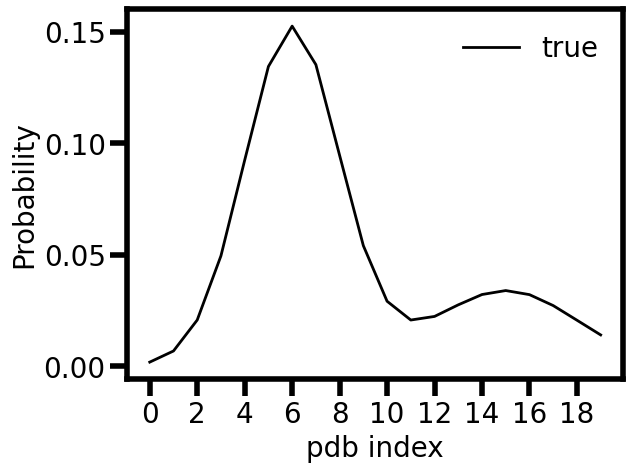

In [17]:
import numpyro.distributions as numpyro_dist


def GaussianMixture1D(weights, means, std_devs):
    weights = jnp.array(weights)
    means = jnp.array(means)
    std_devs = jnp.array(std_devs)
    mixing_dist = numpyro_dist.Categorical(probs=weights/jnp.sum(weights))
    component_dist = numpyro_dist.Normal(loc=means, scale=std_devs) 
    return numpyro_dist.MixtureSameFamily(mixing_dist, component_dist) 

weights = [1., 1./3.]
means = [6., 15.]
std_devs = [2.0, 3.0]
mixture = GaussianMixture1D(weights, means, std_devs)
samples = mixture.sample(jax.random.PRNGKey(0), (10000,))
 
# compute pdf output on a 1d grid
x = jnp.linspace(0, 19, 20)
dx = x[1] - x[0]
    
# normalize output to integrate to 1 on the grid 
true_weights = jnp.exp(mixture.log_prob(x))
true_weights /= dx*true_weights.sum() 
plt.plot(x, true_weights, label='true', color="k")
plt.xticks(jnp.arange(0, 20, 2))
plt.xlabel('pdb index')
plt.ylabel('Probability')  
plt.legend()


In [18]:
nodes = jnp.linspace(0, 19, 20) + 0.5 

results = {}

METHOD ="no_reg"
ensemble_weights, stats = multiplicative_gradient(log_likelihood, true_weights, max_iterations=10000, iter_freq=1, METHOD=METHOD)
results[METHOD] = {"ensemble_weights":ensemble_weights, "stats":stats}

jnp.savez(f"{data_dir}/data_long_run.npz", results=results[METHOD])


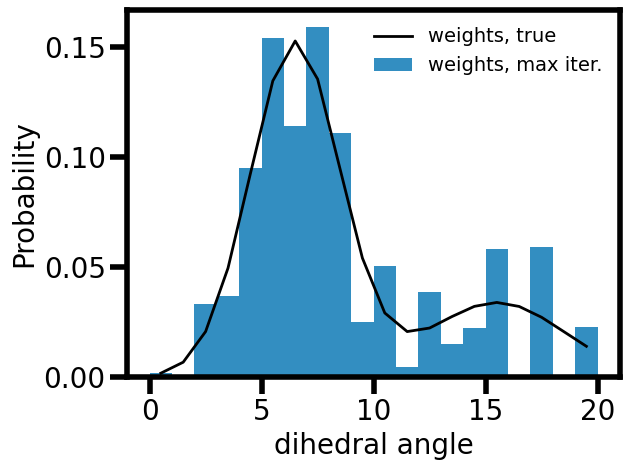

In [19]:

plt.figure()
plt.plot(nodes, true_weights, label='weights, true', color="k")
plt.bar(nodes, results[METHOD]["ensemble_weights"], width=dx, label='weights, max iter.', color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(f"{fig_dir}/weight_true_max_iter.png", dpi=300)



# Find the "early stopped weights":
## 1)gradient tol
## 2) cross validation

In [25]:
data_long_run = jnp.load(f"{data_dir}/data_long_run.npz", allow_pickle=True)
results = data_long_run["results"]
stats = results.item()["stats"]
weights_all = stats["weights"]

# Find gradient tol

In [26]:
num_iterations = weights_all.shape[0]
tol = -jnp.log(0.99)
check_tol = True

log_likelihood = log_likelihood - jnp.max(log_likelihood, 1)[:, jnp.newaxis]
    
# NOTE: we cannot exponentiate this if previous step hasn't happened 
likelihood = jnp.exp(log_likelihood)
    

dists = []
for k in range(num_iterations):
        weights = weights_all[k, :]
        grad = grad_log_prob(weights, likelihood)
        if check_tol:
            gap = jnp.max(grad) - 1
            #print(gap)
            if gap < tol:
                tol_idx = k
                check_tol = False

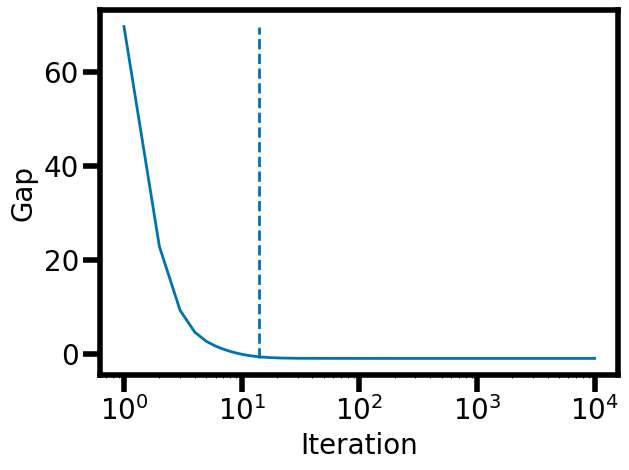

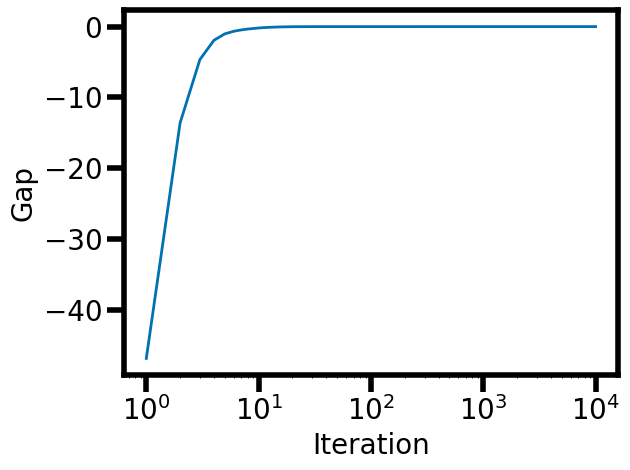

In [28]:
check_idx = 0
losses = stats["loss"]

idx = jnp.arange(check_idx, len(losses), 1)
plt.figure()
gap = jnp.stack(stats["gap"])
idx = jnp.arange(check_idx, len(losses), 1)
plt.semilogx(idx+1, gap[check_idx:], linestyle="-")
plt.vlines(tol_idx, ymin=jnp.min(gap[check_idx:]), ymax=jnp.max(gap[check_idx:]), colors='C0', linestyles="--", label="grad. thresh")
plt.ylabel("Gap")
plt.xlabel("Iteration")
plt.tight_layout()
#plt.savefig(f"{fig_dir}/weight_errors_both_methods.png", dpi=300)

check_idx = 0
losses = stats["loss"]

idx = jnp.arange(check_idx, len(losses), 1)
plt.figure()
gap = jnp.stack(stats["gap"])
idx = jnp.arange(check_idx, len(losses), 1)
plt.semilogx(idx[:-1]+1, jnp.diff(gap[check_idx:]), linestyle="-")
#plt.vlines(tol_idx, ymin=jnp.min(gap[check_idx:]), ymax=jnp.max(gap[check_idx:]), colors='C0', linestyles="--", label="grad. thresh")
plt.ylabel("Gap")
plt.xlabel("Iteration")
plt.tight_layout()



# Find cross validation

In [29]:
import numpy as np
np.random.seed(1)

# Compute 80-20 split
split = 80000
train_idx = np.random.choice(num_images, split, replace=False)
test_idx = np.setdiff1d(np.arange(num_images), train_idx)
likelihood_train = likelihood[train_idx, :]
likelihood_test = likelihood[test_idx, :]

# Run reweighting on the train split
results = {}
METHOD ="no_reg"
ensemble_weights, stats_train = multiplicative_gradient(likelihood_train, true_weights, max_iterations=10000, iter_freq=1, METHOD=METHOD)
results_train = {"ensemble_weights":ensemble_weights, "stats":stats_train}
jnp.savez(f"{data_dir}/data_long_run_train.npz", results=results_train)

# Load data
data_long_run_train = jnp.load(f"{data_dir}/data_long_run_train.npz", allow_pickle=True)
results_train = data_long_run_train["results"]
stats_train = results_train.item()["stats"]
weights_all_train = stats_train["weights"]

# Compute losses on test split
num_iterations = weights_all_train.shape[0]
losses_test = []
for k in range(num_iterations):
        weights = weights_all_train[k, :]
        loss_test = compute_loss(weights, likelihood_test)
        losses_test.append(loss_test)
losses_test = jnp.stack(losses_test)

10


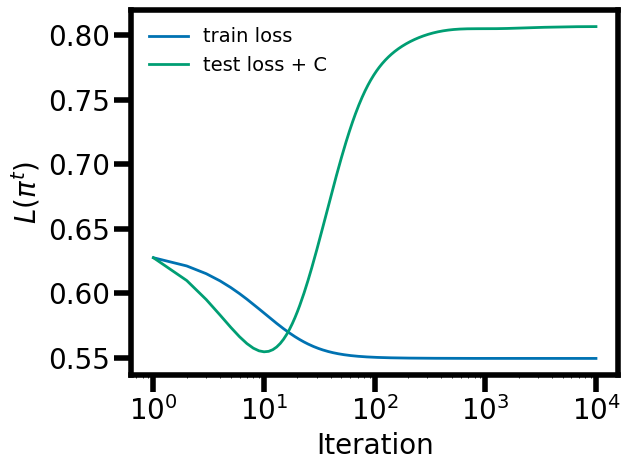

In [30]:
check_idx = 0
losses_train = stats_train["loss"]


# translate test loss to see plot better
losses_test -= losses_test[0] - losses_train[0]

idx = np.arange(check_idx, len(losses_train), 1)
plt.semilogx(idx+1, losses_train[check_idx:], label="train loss")
plt.semilogx(idx+1, losses_test[check_idx:], label="test loss + C")
#plt.vlines(tol_idx, ymin=np.min(losses), ymax=np.max(losses), colors='k')
plt.ylabel(r"$L(\pi^t)$")
plt.xlabel("Iteration")
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(f"{fig_dir}/train_test_hsp90.png", dpi=300)


k = 0
while True:
    if losses_test[k+1] > losses_test[k]:
        cross_val_idx = k + 1
        break
    else:
        k = k+1 
print(cross_val_idx)

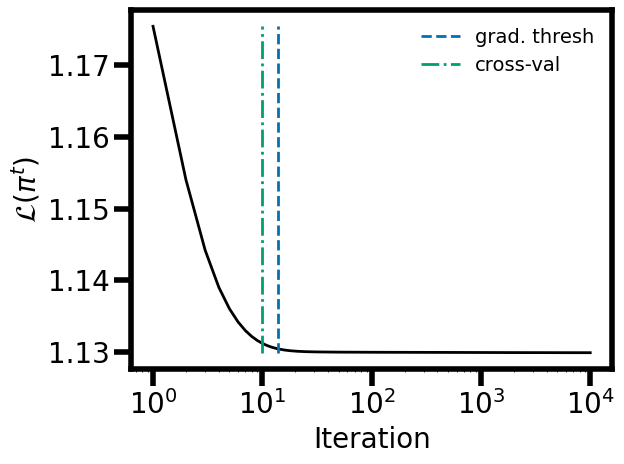

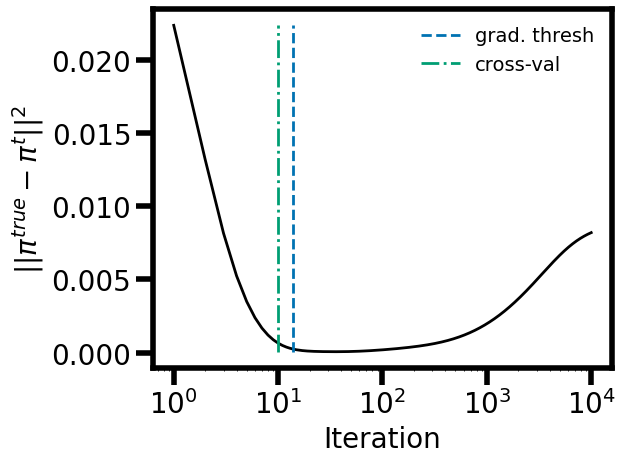

In [31]:
import numpy as np
plt.figure()
plt.rcParams.update({'font.size': 12})

check_idx = 0
METHOD = "no_reg"
losses = stats["loss"]

idx = np.arange(check_idx, len(losses), 1)
plt.semilogx(idx+1, losses[check_idx:], c='k')
plt.vlines(tol_idx, ymin=np.min(losses), ymax=np.max(losses), colors='C0', linestyles="--", label="grad. thresh")
plt.vlines(cross_val_idx, ymin=np.min(losses), ymax=np.max(losses), colors='C1', linestyles="-.", label="cross-val")
plt.ylabel(r"$\mathcal{L}(\pi^t)$")
plt.xlabel("Iteration")
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(f"{fig_dir}/losses.png", dpi=300)

import numpy as np
plt.figure()
plt.rcParams.update({'font.size': 12})

check_idx = 0
METHOD = "no_reg"
errors = stats["weights_error"]
    
idx = np.arange(check_idx, len(losses), 1)
plt.semilogx(idx+1, errors[check_idx:], c='k')
#plt.ylim([np.amin(errors), errors[0]])
plt.vlines(tol_idx, ymin=np.min(errors), ymax=np.max(errors), colors='C0', linestyles="--", label="grad. thresh")
plt.vlines(cross_val_idx, ymin=np.min(errors), ymax=np.max(errors), colors='C1', linestyles="-.", label="cross-val")
plt.ylabel(r"$||\pi^{true} -\pi^t||^2$")
plt.xlabel("Iteration")
plt.legend(fontsize=14)
plt.tight_layout()
#plt.savefig(f"{fig_dir}/weights_error_both_methods.png", dpi=300)
plt.savefig(f"{fig_dir}/weights_error.png", dpi=300)

# Save weights at different indices

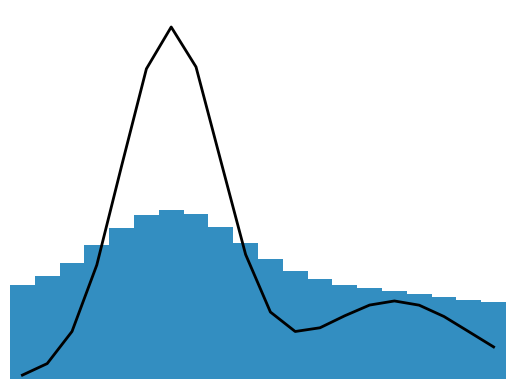

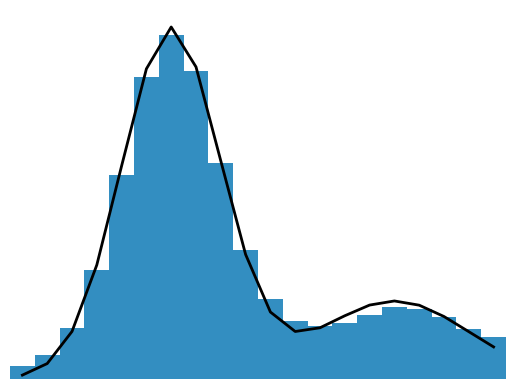

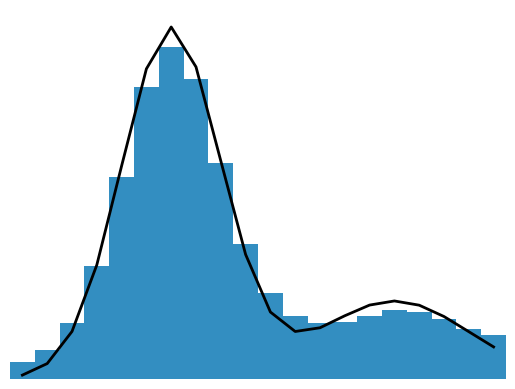

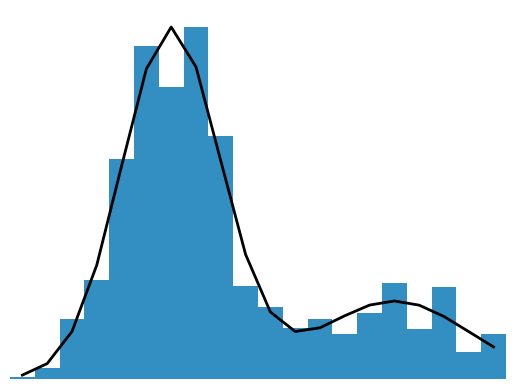

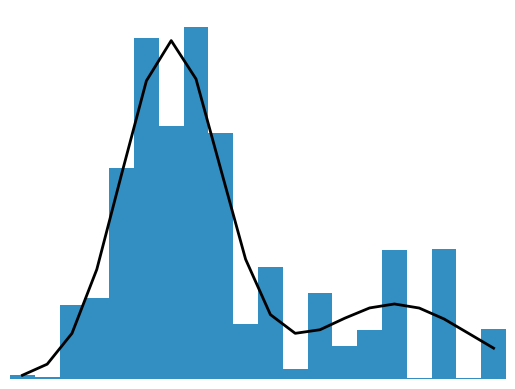

In [32]:
# soft max weights
weights = weights_all[0]
plot_str = "soft_max"
plt.figure()
plt.plot(nodes, true_weights, label='weights, true', color="k")
plt.bar(nodes, weights, width=dx, label='weights, max iter.', color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.xlim([0, 20])
plt.ylabel('Probability')  
#plt.legend(fontsize=14)
plt.savefig(f"{fig_dir}/weights_{plot_str}.png", dpi=300)
plt.axis('off')
plt.savefig(f"{fig_dir}/weights_{plot_str}_no_axis.png", dpi=300)


# gradient threshold
weights = weights_all[tol_idx]
plot_str = "grad_thresh"
plt.figure()
plt.plot(nodes, true_weights, label='weights, true', color="k")
plt.bar(nodes, weights, width=dx, label='weights, max iter.', color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.xlim([0, 20])
plt.ylabel('Probability')  
#plt.legend(fontsize=14)
plt.savefig(f"{fig_dir}/weights_{plot_str}.png", dpi=300)
plt.axis('off')
plt.savefig(f"{fig_dir}/weights_{plot_str}_no_axis.png", dpi=300)

# cross validation
weights = weights_all[cross_val_idx]
plot_str = "cross_val"
plt.figure()
plt.plot(nodes, true_weights, label='weights, true', color="k")
plt.bar(nodes, weights, width=dx, label='weights, max iter.', color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.xlim([0, 20])
plt.ylabel('Probability')  
#plt.legend(fontsize=14)
plt.savefig(f"{fig_dir}/weights_{plot_str}.png", dpi=300)
plt.axis('off')
plt.savefig(f"{fig_dir}/weights_{plot_str}_no_axis.png", dpi=300)



# sort of max_iter
weights = weights_all[1000]
plot_str = "iter_1k"
plt.figure()
plt.plot(nodes, true_weights, label='weights, true', color="k")
plt.bar(nodes, weights, width=dx, label='weights, max iter.', color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.xlim([0, 20])
plt.ylabel('Probability')  
#plt.legend(fontsize=14)
plt.savefig(f"{fig_dir}/weights_{plot_str}.png", dpi=300)
plt.axis('off')
plt.savefig(f"{fig_dir}/weights_{plot_str}_no_axis.png", dpi=300)



# max_iter
weights = weights_all[-1]
plot_str = "max_iter"
plt.figure()
plt.plot(nodes, true_weights, label='weights, true', color="k")
plt.bar(nodes, weights, width=dx, label='weights, max iter.', color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.xlim([0, 20])
plt.ylabel('Probability')  
#plt.legend(fontsize=14)
plt.savefig(f"{fig_dir}/weights_{plot_str}.png", dpi=300)
plt.axis('off')
plt.savefig(f"{fig_dir}/weights_{plot_str}_no_axis.png", dpi=300)






# Save a gif

In [33]:
#import io
#from matplotlib.animation import FuncAnimation
#from PIL import Image
#import matplotlib as mpl
#
#def make_weights_figs(weights_all, weights_idx, nodes, p, dx, fig_dir):
#    fig= plt.figure(figsize=(10, 6))
#    frames = []
#    for idx in range(len(weights_idx)):
#        # Create plot
#        plt.clf()
#        weights = weights_all[idx, :]
#        plt.plot(nodes, p, label='True Prob', c="C0")
#        plt.bar(nodes, weights, width=dx,
#            label='EM Weights', alpha=0.8, color="C1")
#        #plt.step(nodes, counts_observed, label='Observed Counts', where="mid", color="C1")
#        plt.text(x=3, y=0.025, s=f"iteration:{weights_idx[idx]}", fontsize=20)
#        plt.ylim([0, 0.03])
#        # Save frames as images
#        buf = io.BytesIO()
#        plt.savefig(buf, format="png")
#        buf.seek(0)
#        frames.append(Image.open(buf))
#    
#        frames[0].save(
#        f"{fig_dir}/weights_path.gif",
#        save_all=True,
#        append_images=frames[1:],
#        duration=100,
#        loop=0,
#        #subrectangles=True
#    )
#
#
## collect all weights from one run
#METHOD = "no_reg"
#weights_all = results[METHOD]["stats"]["weights"] 
#weights_idx = results[METHOD]["stats"]["weights_idx"]
#make_weights_figs(weights_all, weights_idx, nodes, true_weights, dx, fig_dir)
#
#
#
#
#
#
#
#
#
#
#

# Plot first 10 unregularized weights

In [34]:
#plt.figure() 
#plt.plot(nodes, true_weights, label='true', color="C0")
#plt.bar(nodes, jnp.ones_like(true_weights)/true_weights.shape[0], width=dx, label='EM Weights', color="C1", alpha=0.8)
#plt.xlabel('dihedral angle')
#plt.ylabel('Probability')  
#plt.legend(fontsize=10)
#plt.ylim([0, 0.03])
#plt.text(x=2.8, y=0.025, s=f"iteration:{0}", fontsize=20)
#plt.tight_layout()
#plt.savefig(f"{fig_dir}/weight_iter_{0}.png", dpi=300)
#
#for i in range(10):
#    plt.figure() 
#    plt.plot(nodes, true_weights, label='true', color="C0")
#    plt.bar(nodes, results["reverse_kl"][0]["stats"]["weights"][i+1], width=dx, label='EM Weights', color="C1", alpha=0.8)
#    plt.xlabel('dihedral angle')
#    plt.ylabel('Probability')  
#    plt.legend(fontsize=10)
#    plt.ylim([0, 0.03])
#    plt.text(x=2.8, y=0.025, s=f"iteration:{i+1}", fontsize=20)
#    plt.tight_layout()
#    plt.savefig(f"{fig_dir}/weight_iter_{i+1}.png", dpi=300)
#


In [35]:
#plt.figure()
#plt.rcParams.update({'font.size': 12})
#
#check_idx = 1
#for i in range(num_regs):
#
#    #METHOD = "forward_kl"
#    #losses = results[METHOD][i]["stats"]["gap_alt"]
#    
#    #idx = np.arange(check_idx, len(losses), 1)
#    #plt.plot(idx, losses[check_idx:], color=colors[i], linestyle="-")
#
#    METHOD = "reverse_kl"
#    losses = results[METHOD][i]["stats"]["gap_alt"]
#    
#    idx = np.arange(check_idx, len(losses), 1)
#    plt.plot(idx, losses[check_idx:], color=colors[i], linestyle="--")
#
#plt.ylabel("gap")
#plt.xlabel("Iteration")
#plt.title("weight error of forward/rev. kl regularization")
#plt.tight_layout()
#plt.savefig(f"{fig_dir}/gappppp_both_methods.png", dpi=300)
#plt.show()